<a href="https://colab.research.google.com/github/sambee5/data-science-coursework/blob/main/Unit3/SamarthBUnit3ExercisesSF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install preliz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 519.6/519.6 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.8/108.8 kB 11.7 MB/s eta 0:00:00


In [ ]:
import preliz as pz

# Unit 3 Exercises: Delightfully Diverse Distirbutions

Use these exercises as a chance to explore the probability distributions (dists) from the pymc and preliz libraries. [Moments](https://en.wikipedia.org/wiki/Moment_(mathematics)), the main subject of these exercises, are a great way to describe dists, but there's another  way: [maximum entropy](https://en.wikipedia.org/wiki/Maximum_entropy_probability_distribution#Other_examples), which, although important, we will not cover in detail.

Here's what we'll cover in this Unit's exercises:
- The first four moments: mean, variance, skew, and kurtosis, as well as the support.
- Single variable continuous distributions.
- Single variable discrete distriutions


Why do we need to know this stuff? Two reasons:
- Probability distributions are required to set priors and likelihoods in pymc.
- Randomness and uncertainty are not well defined mathematically, but probability and probability distributions are.

With that in mind, think of these exercises as an oppurtunity to explore the ways we can be uncertain, or the ways things can be random.

## The First Four Moments: Mean, Variance, Skew, and Kurtosis

When we talk about a probablity dist, we often care about at four things:
- The expected value, or where a distribution is centered (mean)
- The amount of variation from that centered value (variation)
- Whether or not our distribution favors, leans towards, or skews towards certain values. (skew)
- How often to expect unusually high or low values. (kurtosis)

### Playing with Beta

**Task1**:

Plot a [preliZ Beta distribution](https://preliz.readthedocs.io/en/latest/api_reference.html#preliz.distributions.beta.Beta) with $α=1$ and $β=1$.

<Axes: >

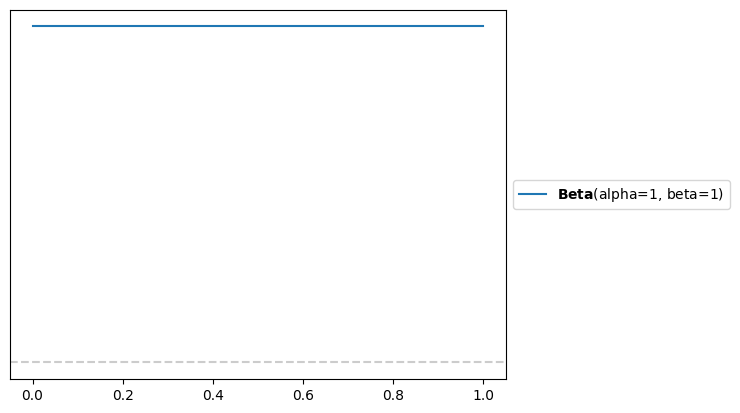

In [ ]:
pz.Beta(alpha = 1, beta = 1).plot_pdf()

**Task2**:

Find the mean, variance, skew, and kurtosis of a $Beta(1,1)$ distribution. This is the same as asking for the first four moments of a $Beta(1,1)$ distribution.

*Hint*: preliZ has built in function that does this for you.

In [ ]:
'''
I realize that moments() gets all of these moments, but I wanted to experiment
with the different methods
'''
mean = pz.Beta(1,1).mean()
variance = pz.Beta(1,1).moments()[1]
skew = pz.Beta(1,1).skewness()
kurtosis = pz.Beta(1,1).kurtosis()

mean, variance, skew, kurtosis

(np.float64(0.5), np.float64(0.08333333333333333), array(0.), np.float64(-1.2))

Mean: 0.5

Variance: 0.0833333333333333

Skew: 0

Kurtosis: -1.2

**Task3**:

Plot the following distributions on seperate graphs: $Beta(1,1)$, $Beta(0.9,0.9)$, $Beta(2,1)$, $Beta(1,2)$, $Beta(7,11)$, $Beta(96,42)$, $Beta(5,5)$, $Beta(500,500)$, $Beta(0.8,0.9)$.

Then, determine which of those distribtuions has:
- the largest/smallest mean
- the largest/smallest variance
- the largest/smallest skew
- the largest/smallest kurtosis

and show the code you used to find that information.

<Axes: >

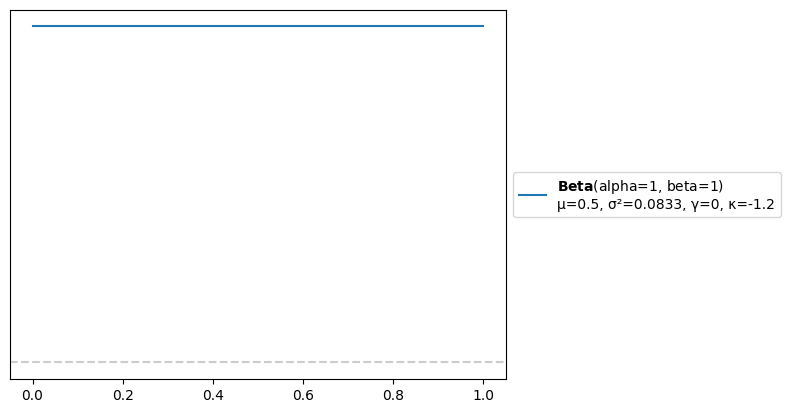

In [ ]:
pz.Beta(alpha = 1, beta = 1).plot_pdf(moments="mvsk")

<Axes: >

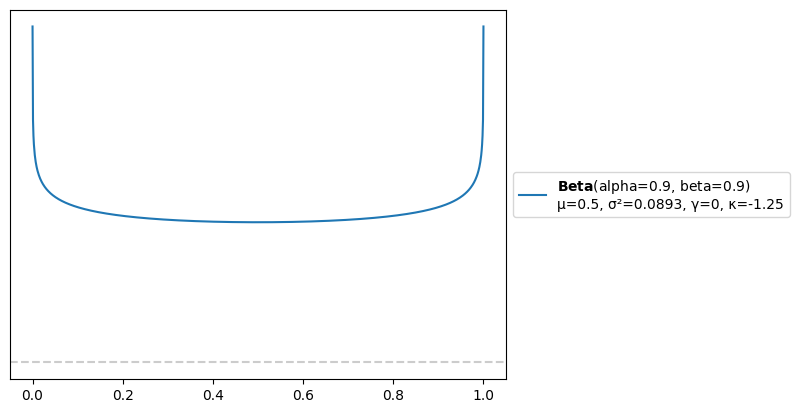

In [ ]:
pz.Beta(alpha = 0.9, beta = 0.9).plot_pdf(moments="mvsk")

<Axes: >

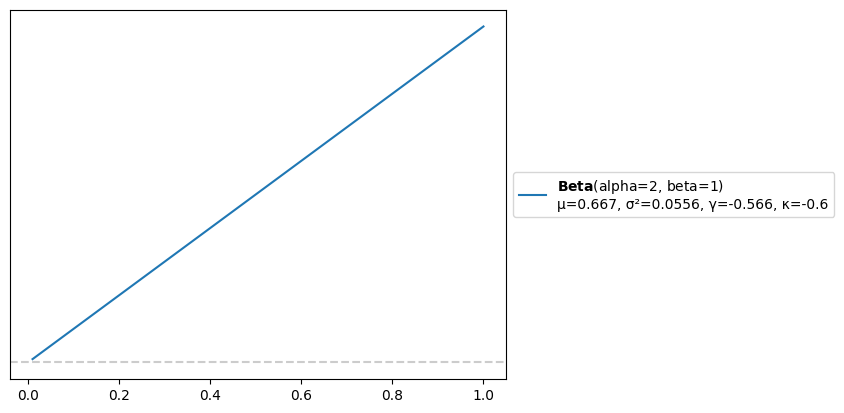

In [ ]:
pz.Beta(alpha = 2, beta = 1).plot_pdf(moments="mvsk")

<Axes: >

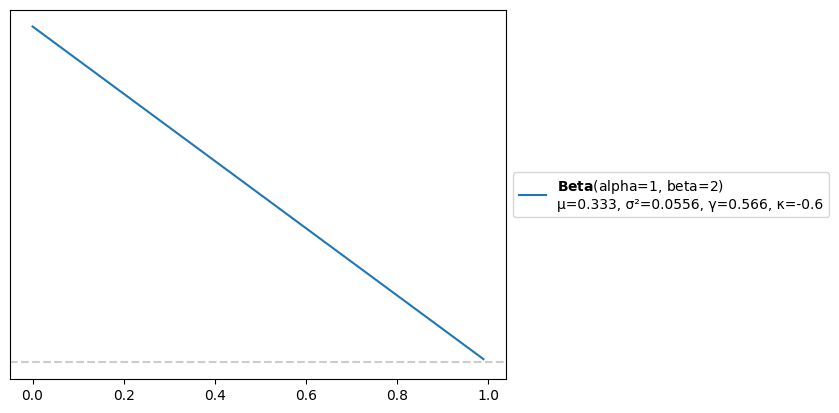

In [ ]:
pz.Beta(alpha = 1, beta = 2).plot_pdf(moments="mvsk")

<Axes: >

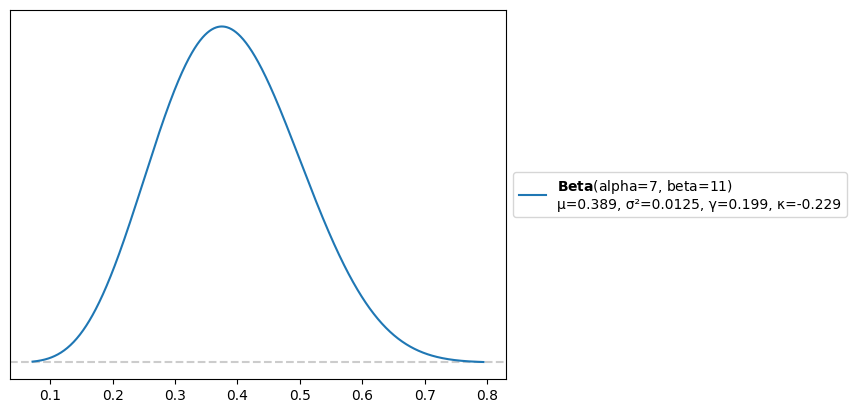

In [ ]:
pz.Beta(alpha = 7, beta = 11).plot_pdf(moments="mvsk")

<Axes: >

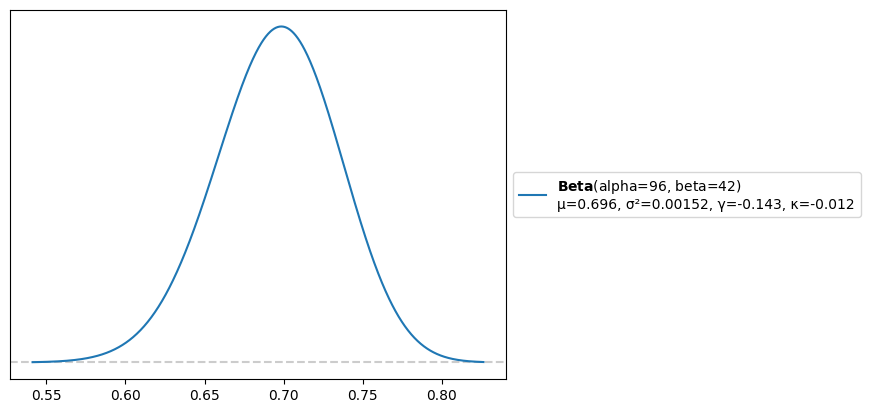

In [ ]:
pz.Beta(alpha = 96, beta = 42).plot_pdf(moments="mvsk")

<Axes: >

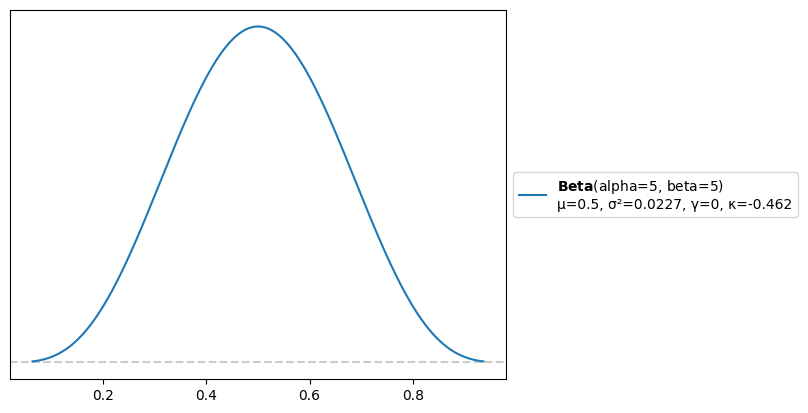

In [ ]:
pz.Beta(alpha = 5, beta = 5).plot_pdf(moments="mvsk")

<Axes: >

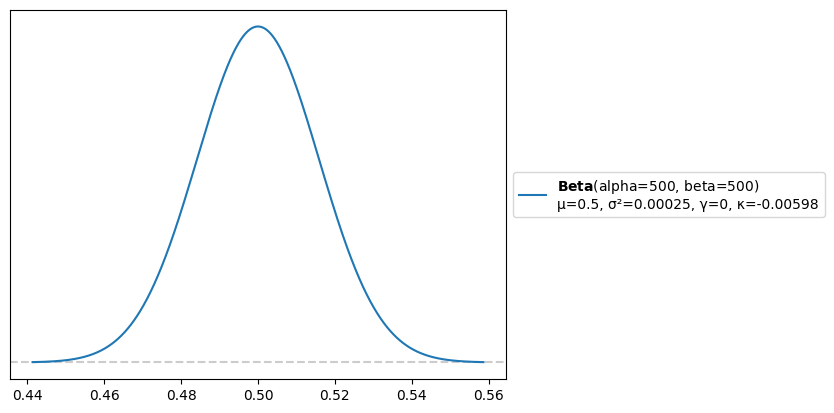

In [ ]:
pz.Beta(alpha = 500, beta = 500).plot_pdf(moments="mvsk")

<Axes: >

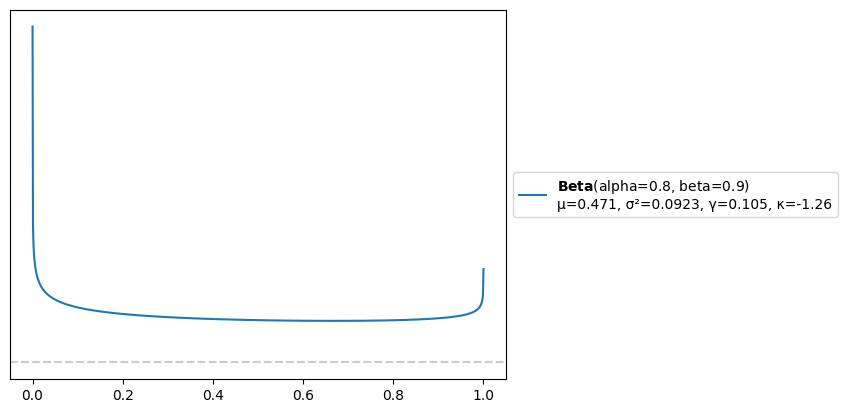

In [ ]:
pz.Beta(alpha = 0.8, beta = 0.9).plot_pdf(moments="mvsk")

In [ ]:
beta_distributions = [
    pz.Beta(alpha=1, beta=1),
    pz.Beta(alpha=0.9, beta=0.9),
    pz.Beta(alpha=2, beta=1),
    pz.Beta(alpha=1, beta=2),
    pz.Beta(alpha=7, beta=11),
    pz.Beta(alpha=96, beta=42),
    pz.Beta(alpha=5, beta=5),
    pz.Beta(alpha=500, beta=500),
    pz.Beta(alpha=0.8, beta=0.9),
]

#uses list comprehension to get the kurtosis for every beta distribution I want. can be easily replicated for other moments
#I used w3schools to remind myself how to do this in python
mean_values = [(dist.mean(), f'Beta(alpha={dist.alpha}, beta={dist.beta})') for dist in beta_distributions]
variance_values = [(dist.moments()[1], f'Beta(alpha={dist.alpha}, beta={dist.beta})') for dist in beta_distributions]
skewness_values = [(dist.skewness(), f'Beta(alpha={dist.alpha}, beta={dist.beta})') for dist in beta_distributions]
kurtosis_values = [(dist.kurtosis(), f"Beta(alpha={dist.alpha}, beta={dist.beta})") for dist in beta_distributions]


#sort all the moments
sorted_kurtosis = sorted(kurtosis_values)
sorted_mean = sorted(mean_values)
sorted_skewness = sorted(skewness_values)
sorted_variance = sorted(variance_values)

#print out each moment. Numpy makes this a bit painful to read, so I wrote it in text after so it's easier
print(f'Largest Mean: {sorted_mean[-1]}, Smallest Mean: {sorted_mean[0]}')
print(f'Largest Variance: {sorted_variance[-1]}, Smallest Variance: {sorted_variance[0]}')
print(f'Largest Skew: {sorted_skewness[-1]}, Smallest Skew: {sorted_skewness[0]}')
print(f'Largest Kurtosis: {sorted_kurtosis[-1]}, Smallest Kurtosis: {sorted_kurtosis[0]}')


Largest Mean: (np.float64(0.6956521739130435), 'Beta(alpha=96.0, beta=42.0)'), Smallest Mean: (np.float64(0.3333333333333333), 'Beta(alpha=1.0, beta=2.0)')
Largest Variance: (np.float64(0.09227220299884659), 'Beta(alpha=0.8, beta=0.9)'), Smallest Variance: (np.float64(0.00024975024975024975), 'Beta(alpha=500.0, beta=500.0)')
Largest Skew: (np.float64(0.565685424949238), 'Beta(alpha=1.0, beta=2.0)'), Smallest Skew: (np.float64(-0.565685424949238), 'Beta(alpha=2.0, beta=1.0)')
Largest Kurtosis: (np.float64(-0.005982053838484547), 'Beta(alpha=500.0, beta=500.0)'), Smallest Kurtosis: (np.float64(-1.263657274295572), 'Beta(alpha=0.8, beta=0.9)')


Largest Mean: 0.6956521739130435, Beta(alpha=96.0, beta=42.0)

Smallest Mean: 0.3333333333333333, Beta(alpha=1.0, beta=2.0)


---



Largest Variance: 0.09227220299884659, Beta(alpha=0.8, beta=0.9)

Smallest Variance: 0.00024975024975024975, Beta(alpha=500.0, beta=500.0)


---


Largest Skew: 0.565685424949238, Beta(alpha=1.0, beta=2.0)

Smallest Skew: -0.565685424949238, Beta(alpha=2.0, beta=1.0)


---


Largest Kurtosis: -0.005982053838484547, Beta(alpha=500.0, beta=500.0)

Smallest Kurtosis: -1.263657274295572, Beta(alpha=0.8, beta=0.9)


###Playing with other Continuous Distributions

For the remaining tasks, make sure to continue to use the [preliZ documentation](https://preliz.readthedocs.io/en/latest/api_reference.html).

The [wikipedia pages for each of the probability distributions](https://en.wikipedia.org/wiki/List_of_probability_distributions) are also great resources.

[Wolfram Alpha](https://www.wolframalpha.com/examples/mathematics/probability/probability-distributions) is another great resource as well.

**Task4**:

Plot the pdfs of each of the following distributions on the same graph: $Normal(μ=0,σ=1)$, $StudentT(ν=5,μ=0,σ=1)$

Then, plot these on the same graph: $Exponential(λ=1/2)$, $Gamma(α=2,β=1)$, $HalfStudentT(ν=5,σ1)$

For the t distribution and half t, use

```
support=(-4,4)
```
and
```
support=(0,4)
```
respectively, inside the plot_pdf function.


<Axes: >

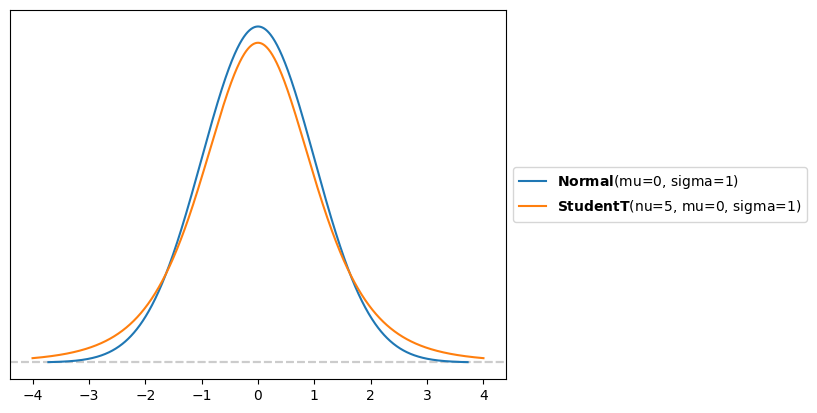

In [ ]:
pz.Normal(mu = 0, sigma = 1).plot_pdf()
pz.StudentT(nu = 5, mu = 0, sigma = 1).plot_pdf(support=(-4,4))

<Axes: >

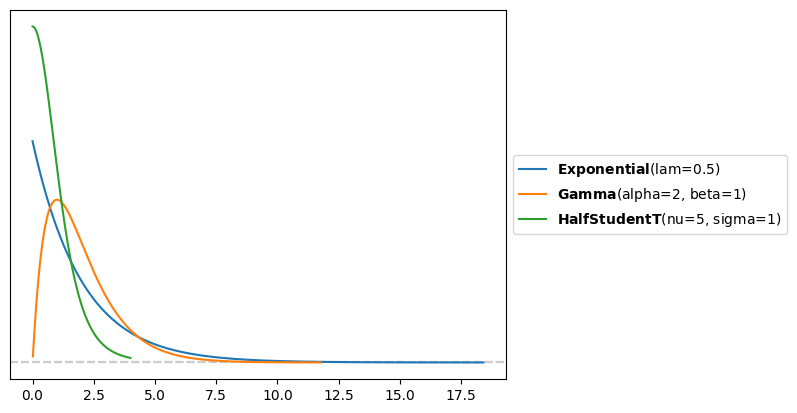

In [ ]:
pz.Exponential(lam = 1/2).plot_pdf()
pz.Gamma(alpha = 2, beta = 1).plot_pdf()
pz.HalfStudentT(nu = 5, sigma = 1).plot_pdf(support=(0,4))

**Task5:**

Find the first four moments of the the distributions from Task4. Then,

Determine which of those five dsitributions has the largest and smallest: mean, variance, skew, and kurtosis. (Ignore skew and kurtosis for the Half StudentT)

Those distributions are repeated here for conveniencce: $Normal(μ=0,σ=1)$, $StudentT(ν=5,μ=0,σ=1)$,  $Exponential(λ=1/2)$, $Gamma(α=2,β=1)$, $HalfStudentT(ν=5,σ=1)$

In [ ]:
pz.Normal(mu = 0, sigma = 1).moments()

[np.float64(0.0), np.float64(1.0), 0, 0]

In [ ]:
pz.StudentT(nu = 5, mu = 0, sigma = 1).moments()

[np.float64(0.0), np.float64(1.6666666666666667), 0, np.float64(6.0)]

In [ ]:
pz.Exponential(lam = 1/2).moments()

[np.float64(2.0), np.float64(4.0), 2, 6]

In [ ]:
pz.Gamma(alpha = 2, beta = 1).moments()

[np.float64(2.0),
 np.float64(2.0),
 np.float64(1.414213562373095),
 np.float64(3.0)]

In [ ]:
pz.HalfStudentT(nu = 5, sigma = 1).moments("mv")

[np.float64(0.9490167245562356), np.float64(0.7660339231792207)]

The Normal and Student T distribution have the smallest mean since both are 0. The Exponential and Gamma distribution both have the largest mean since both are 2.

The Half Student T distribution has the smallest variance. The Exponential distribution has the largest variance.

The Normal and Student T distribution have the smallest skew since both are at 0. The Exponential distribution has the largest skew.

The Student T distribution has the largest kurtosis. The Normal distribution has the smallest kurtosis.

**Task6**:

What x values do the Exponenital, Gamma, HalfSutdentT, and HalfNormal functions support? Why plot them on the same graph?

What x values do the Normal and T distribution support? Why plot them on the same graph?

What x values does the Beta distribution support?

The Exponential, Gamma, HalfStudentT, and HalfNormal distributions are in the domain of positive real numbers. It's important to plot them on the same graph to reach this conclusion visually.

The domain of the Normal and T distribution are all real numbers, positive and negative. It's important to plot them on the same graph to develop an intuition of how the graph looks, and how this affects their mean, variance, and kurtosis.

The Beta distribution supports x values from [0, 1].

**Task7**:

Can a distribution with support $[0,∞]$ have negative (or left) skew? If so, plot that specific distribution.

<Axes: >

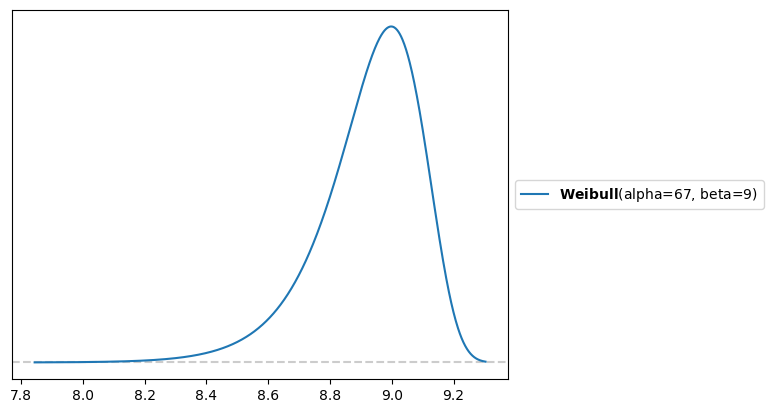

In [ ]:
pz.Weibull(alpha=67, beta=9).plot_pdf()

**Task8**:

Name a distribution that supports the real numbers with variance equal to 1, 0 skew, and 0 kurtosis.

<Axes: >

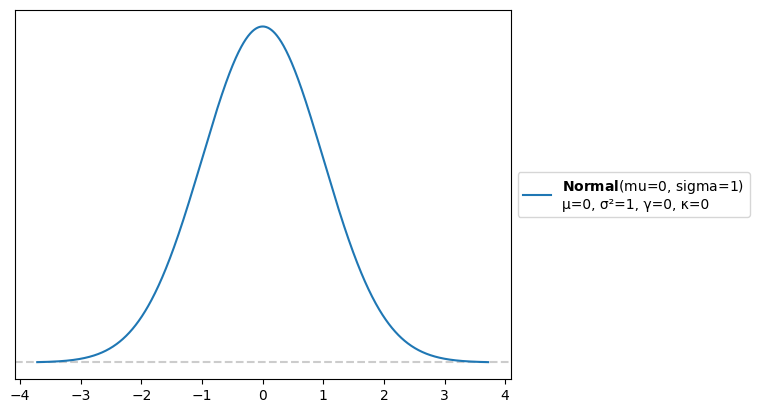

In [ ]:
pz.Normal(mu=0, sigma=1).plot_pdf(moments='mvsk')

The normal distribution fits these parameters!

**Task9**:

Name a distribution with support $(-∞,∞)$ and that has negative skew.

(-inf, inf)

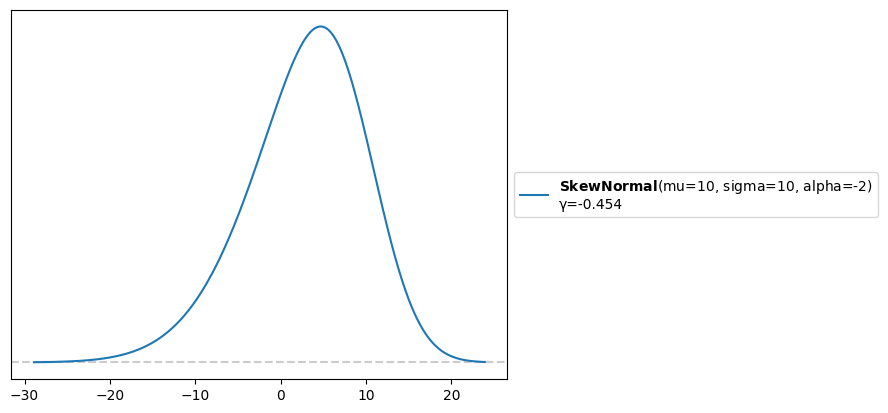

In [ ]:
pz.SkewNormal(mu=10,sigma=10, alpha=-2).plot_pdf(moments='s')
pz.SkewNormal(mu=10,sigma=10, alpha=-2).support

The SkewNormal distribution fits the parameters!

**Optional Task**:

What are the maximum entropy conditions for the normal and gamma distributions?

Normal:

*   Support: $\mathbb{R}$
*   Mean: $0$
*   Variance: $1$

Gamma:
*   Support: $(0,\infty)$
*   Mean: $2$
*   Variance: $2$


###Playing with Discrete Distributions

**Task9**:

Plot the pdfs (techincally the pmfs) of the following distributions: $Bernoulli(p=0.7)$, $Binomial(n=10,p=0.7)$, $Poisson(μ=7)$, $Geometric(p=0.7)$, $HyperGeometric(N=50,k=35,n=15)$, $Categorical(p=[0.05,0.3,0.05,0.1,0.2,0.4])$

Additionally, compute the first four moments for all those distributions--except the Categorical distribution.

<Axes: >

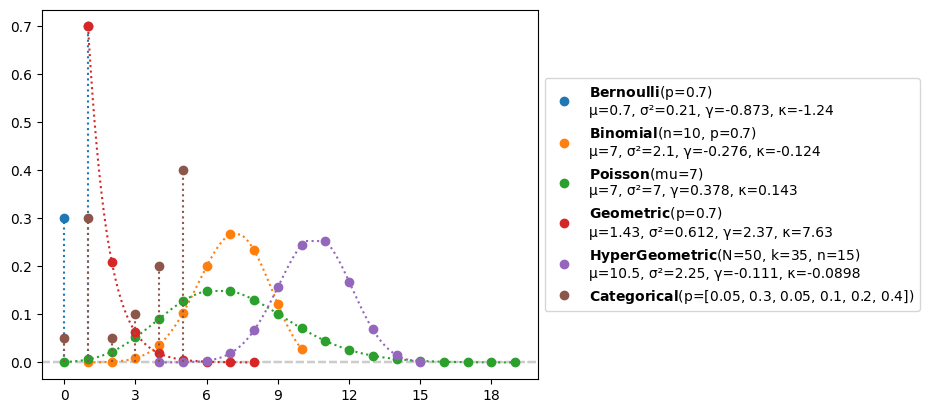

In [ ]:
pz.Bernoulli(p=0.7).plot_pdf(moments='mvsk')
pz.Binomial(n=10, p=0.7).plot_pdf(moments='mvsk')
pz.Poisson(mu=7).plot_pdf(moments='mvsk')
pz.Geometric(p=0.7).plot_pdf(moments='mvsk')
pz.HyperGeometric(N=50, k=35, n=15).plot_pdf(moments='mvsk')
pz.Categorical(p=[0.05, 0.3, 0.05, 0.1, 0.2, 0.4]).plot_pdf()

**Task10**:

Describe what processes "generate" each of the previous discrete distributions models. Also report their support.

Here's a spicier way to phrase the question: describe these distributions' maximum entropy conditions in english.

Hint: Make sure to read any of the: preliZ documentation, relevant wikipedia articles, or wolfram alpha.


Bernoulli: describes the probability of makes/misses (success/failure) as a number 0-1. This implies that their support is also 0-1.

Binomial: takes in parameters n and p and predicts the number of successes within n experiments. This is a discrete distribution because performing experiments and recording data is a discrete process, so the support is all positive integers.

Poisson: I feel this distribution deviates from the traditional definition! It describes probability of an event taking place. I wonder if this would be a very useful likelihood because it seems like it's a good way to represent the probability of the data part of Baye's rule. The support of the distribution is all natural numbers beginning at 0.

Geometric: this distribution is the probability of repeating a trial until there is 1 success. The support is natural numbers greater than or equal to0 because you can't have negative trials but you can have 0 trials.

HyperGeometric: discrete distribution that describes the probability of getting k successes within n trials within a finite population. The support is (max(0, n-N+K), min(k,n)).

Categorical: describes the possible results of which category something can be in out of all possible categories. The support is just 1-k (num of categories)


To research a bit about these distributions, I took a glance at their respective wikipedia pages.

